In [228]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression,SGDClassifier
from sklearn.preprocessing import StandardScaler,PolynomialFeatures
from sklearn.metrics import r2_score
from sklearn.pipeline import Pipeline

In [229]:
x = 6 * np.random.rand(200,1) - 3
y = (0.8 * x ** 2) + (0.9 * x) + 2 + np.random.randn(200,1)
# y = 0.8*x^2 + 0.9*x + 2 + random

Text(0, 0.5, 'Y')

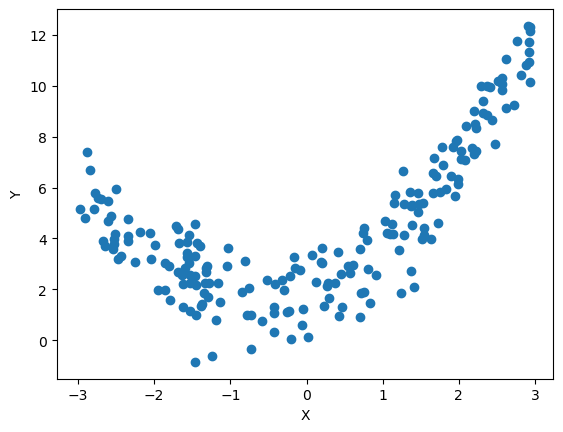

In [230]:
plt.scatter(x,y)
plt.xlabel("X")
plt.ylabel("Y")

In [231]:
x_train,x_test,y_train,y_test = train_test_split(x,y,random_state = 0, test_size = 0.2)

In [232]:
lr = LinearRegression()
lr.fit(x_train,y_train)

LinearRegression()

In [233]:
y_pred = lr.predict(x_test)

Text(0, 0.5, 'Y')

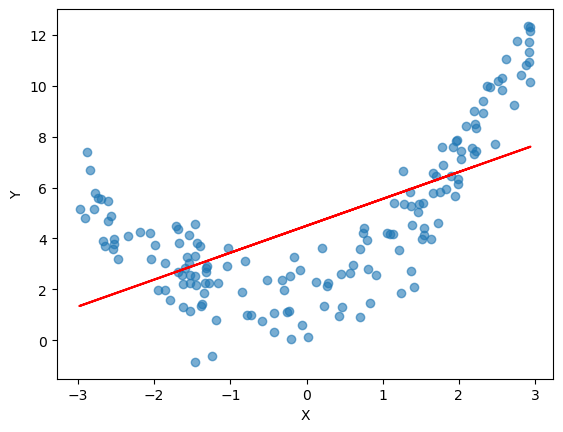

In [234]:
plt.scatter(x_train,y_train, alpha=0.6)
plt.plot(x_train,lr.predict(x_train),color = "Red")
plt.xlabel("X")
plt.ylabel("Y")

In [235]:
print(r2_score(y_test,y_pred))

0.32966928585514144


In [236]:
print(lr.coef_)
print(lr.intercept_)

[[1.05746343]]
[4.49662126]


### Applying Polynomial Regression

In [237]:
poly = PolynomialFeatures(degree = 2, include_bias = True) 
# PolynomialFeatures(degree = 2) return x^0  x^1  x^2 , If degree = 3 then it return x^0  x^1  x^2  x^3
# If we apply include_bias = False then it will not return x^0 and it will return only  x^1  x^2
x_train_trans = poly.fit_transform(x_train)
x_test_trans = poly.transform(x_test)

In [238]:
print(x_train.shape)
print(x_train_trans.shape)

(160, 1)
(160, 3)


In [239]:
print(x_train[0])
print(x_train_trans[0])

[2.19884945]
[1.         2.19884945 4.83493891]


In [240]:
lr = LinearRegression()
lr.fit(x_train_trans,y_train)

LinearRegression()

In [241]:
y_pred_trans = lr.predict(x_test_trans)

In [242]:
x_new  = np.linspace(-3,3,200).reshape(200,1)
x_new_poly = poly.transform(x_new)
y_new = lr.predict(x_new_poly)

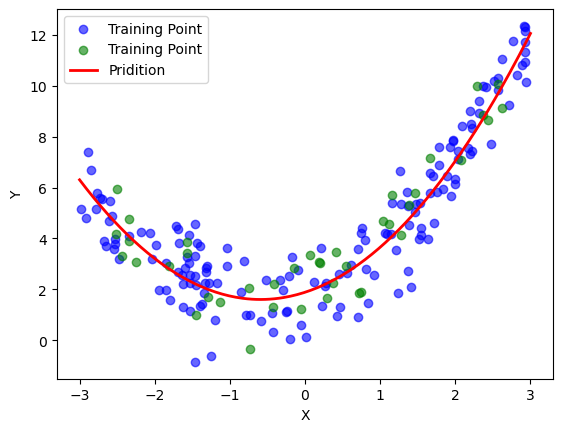

In [243]:
plt.scatter(x_train,y_train,label = "Training Point", color = "Blue", alpha=0.6)
plt.scatter(x_test,y_test,label = "Training Point",color = "Green", alpha=0.6)
plt.plot(x_new,y_new,linewidth = 2,label = "Pridition",color = "RED")
plt.xlabel("X")
plt.ylabel("Y")
plt.legend()
plt.show()

In [244]:
print(r2_score(y_test,y_pred_trans))

0.8698346114291933


In [245]:
print(lr.coef_)
print(lr.intercept_)

[[0.         0.95841287 0.81033638]]
[1.88516446]


In [271]:
class PolynomialRegression:

    def __init__(self, degree=1):
        self.degree = degree
        self.is_fitted = False

    def fit(self, x_train, y_train):
        self.x_train = x_train
        self.y_train = y_train

        self.poly = PolynomialFeatures(degree=self.degree)
        x_train_poly = self.poly.fit_transform(x_train)

        self.model = LinearRegression()
        self.model.fit(x_train_poly, y_train)

        self.is_fitted = True

    def predict(self, x):

        x_poly = self.poly.transform(x)
        y_pred = self.model.predict(x_poly)
        return y_pred

    def graph(self):

        x_plot = np.linspace(
            self.x_train.min(),
            self.x_train.max(),
            300
        ).reshape(-1, 1)

        y_plot = self.predict(x_plot)

        plt.scatter(self.x_train, self.y_train,color="Blue", alpha=0.6, label="Training Data")
        plt.plot(x_plot, y_plot,linewidth=2, color="red",label=f"Degree {self.degree}")
        plt.xlabel("X")
        plt.ylabel("Y")
        plt.axis([-3.5, 3.5, -3, 20])
        plt.title("Polynomial Regression")
        plt.legend()
        plt.show()
        
    def r2_score(self,y_test,y_pred):
        from sklearn.metrics import r2_score
        return r2_score(y_test,y_pred)

In [290]:
pr = PolynomialRegression(20)
pr.fit(x_train,y_train)

In [291]:
y_pred = pr.predict(x_test)

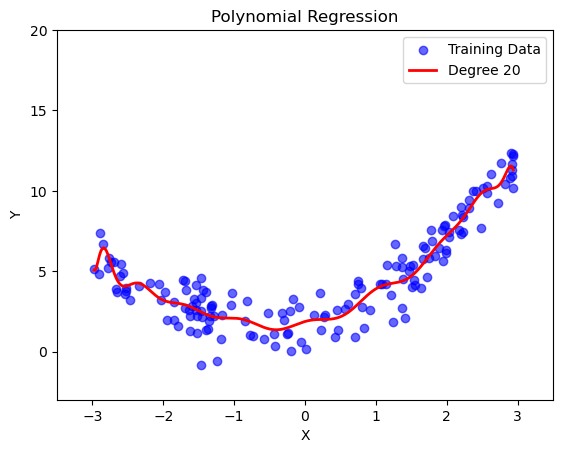

In [292]:
pr.graph()

In [293]:
pr.r2_score(y_test,y_pred)

0.8538641902812636